In [ ]:
!pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 36.2 MB/s eta 0:00:00


In [ ]:
import os
import re
import kagglehub
import glob
import urllib.request
import zipfile
import numpy as np
import scipy.io
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.signal import welch
from scipy.stats import skew, kurtosis

# Ensure required interactive packages are installed
try:
    import plotly.express as px
    import plotly.graph_objects as go
except ImportError:
    !pip install plotly
    import plotly.express as px
    import plotly.graph_objects as go

try:
    import umap
except ImportError:
    !pip install umap-learn
    import umap.umap_ as umap

import kagglehub

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (14, 8)

## Load First 20 Subjects Sequentially from Ninapro DB2 Dataset

In [ ]:

# 1. ATTACH DATASET & LOCATE FILES VIA KAGGLEHUB
# =========================================================
print("Attaching dataset via kagglehub...")
path = kagglehub.dataset_download("quddusikashaf/ninapro-db2")

print(f"Reading dataset directly from: {path}")

# Find all .mat files in the input path
mat_files = glob.glob(f"{path}/**/*.mat", recursive=True)
print(f"Success! Total .mat files detected: {len(mat_files)}")

# Filter for Exercise 1 files across all subjects
ex1_files = [f for f in mat_files if "_E1_" in f.upper()]

if not ex1_files:
    raise ValueError(
        "No Exercise 1 files found. Please make sure the dataset 'ninapro-db2' "
        "is added to your Kaggle Notebook input."
    )


# Sort strictly by subject number (S1, S2, ..., S20)
def extract_subject_num(filepath):
    filename = os.path.basename(filepath)
    match = re.search(r"S(\d+)_E1", filename.upper())
    return int(match.group(1)) if match else 999


ex1_files_sorted = sorted(ex1_files, key=extract_subject_num)

# RAM SAFETY CONTROL: Process the first 20 subjects
MAX_SUBJECTS = 20

subject_data = {}
for file_path in ex1_files_sorted:
    if len(subject_data) >= MAX_SUBJECTS:
        print(f"\nReached limit of {MAX_SUBJECTS} subjects ")
        break

    filename = os.path.basename(file_path)
    match = re.search(r"S(\d+)_E1", filename.upper())
    if match:
        subject_id_num = int(match.group(1))
        subject_key = f"Subject {subject_id_num}"

        print(f"Loading {subject_key} file: {file_path}")
        mat_data = scipy.io.loadmat(file_path)

        # Downcast emg array to float32 to reduce RAM usage by 50%
        subject_data[subject_key] = {
            "emg": mat_data["emg"].astype("float32"),
            "restimulus": mat_data["restimulus"].flatten(),
        }

print(f"\nLoaded data for {len(subject_data)} subjects")

Attaching dataset via kagglehub...


100%|██████████| 17.0G/17.0G [03:40<00:00, 82.7MB/s]

Extracting files...


Reading dataset directly from: /root/.cache/kagglehub/datasets/quddusikashaf/ninapro-db2/versions/2
Success! Total .mat files detected: 120
Loading Subject 1 file: /root/.cache/kagglehub/datasets/quddusikashaf/ninapro-db2/versions/2/DB2_s1/DB2_s1/S1_E1_A1.mat
Loading Subject 2 file: /root/.cache/kagglehub/datasets/quddusikashaf/ninapro-db2/versions/2/DB2_s2/DB2_s2/S2_E1_A1.mat
Loading Subject 3 file: /root/.cache/kagglehub/datasets/quddusikashaf/ninapro-db2/versions/2/DB2_s3/DB2_s3/S3_E1_A1.mat
Loading Subject 4 file: /root/.cache/kagglehub/datasets/quddusikashaf/ninapro-db2/versions/2/DB2_s4/DB2_s4/S4_E1_A1.mat
Loading Subject 5 file: /root/.cache/kagglehub/datasets/quddusikashaf/ninapro-db2/versions/2/DB2_s5/DB2_s5/S5_E1_A1.mat
Loading Subject 6 file: /root/.cache/kagglehub/datasets/quddusikashaf/ninapro-db2/versions/2/DB2_s6/DB2_s6/S6_E1_A1.mat
Loading Subject 7 file: /root/.cache/kagglehub/datasets/quddusikashaf/ninapro-db2/versions/2/DB2_s7/DB2_s7/S7_E1_A1.mat
Loading Subject 8 fi

##Raw DataFrame Inspection

In [ ]:
# Convert the already-loaded subject_data dictionary into pandas DataFrames for all 20 subjects
subject_dfs = {}

for subject_key, data in subject_data.items():
    emg_data = data["emg"]
    restimulus = data["restimulus"]

    # 1. Create channel column names
    num_channels = emg_data.shape[1]
    channel_names = [f"EMG_Ch{i+1}" for i in range(num_channels)]

    # 2. Construct inspection DataFrame
    df_raw = pd.DataFrame(emg_data, columns=channel_names)
    df_raw["restimulus"] = restimulus

    # Store in new dictionary
    subject_dfs[subject_key] = df_raw
    print(f"Constructed {subject_key} DataFrame with shape: {df_raw.shape}")

# 3. Sanity check: Inspect the head of Subject 1
print("\n--- Sanity Check: Head of Subject 1 ---")
print(subject_dfs["Subject 1"].head())

Constructed Subject 1 DataFrame with shape: (1808331, 13)
Constructed Subject 2 DataFrame with shape: (1803711, 13)
Constructed Subject 3 DataFrame with shape: (1795150, 13)
Constructed Subject 4 DataFrame with shape: (1797647, 13)
Constructed Subject 5 DataFrame with shape: (1801513, 13)
Constructed Subject 6 DataFrame with shape: (1797578, 13)
Constructed Subject 7 DataFrame with shape: (1796292, 13)
Constructed Subject 8 DataFrame with shape: (1803766, 13)
Constructed Subject 9 DataFrame with shape: (1801456, 13)
Constructed Subject 10 DataFrame with shape: (1805836, 13)
Constructed Subject 11 DataFrame with shape: (1803896, 13)
Constructed Subject 12 DataFrame with shape: (1797214, 13)
Constructed Subject 13 DataFrame with shape: (1801392, 13)
Constructed Subject 14 DataFrame with shape: (1804139, 13)
Constructed Subject 15 DataFrame with shape: (1804393, 13)
Constructed Subject 16 DataFrame with shape: (1801903, 13)
Constructed Subject 17 DataFrame with shape: (1804768, 13)
Constr

##SECTION A — Dataset Metadata Summary Table

In [ ]:
#  Dataset Metadata & Summary Table (Optimized for 20 Subjects)


total_loaded_subjects = len(subject_data)
total_mat_files = len(ex1_files_sorted[:total_loaded_subjects])

# Calculate total raw samples from memory directly without re-reading files from disk
total_raw_samples = sum(data["emg"].shape[0] for data in subject_data.values())

# Get sample data from the first loaded subject for feature/channel calculations
first_subject_key = list(subject_data.keys())[0]
sample_emg = subject_data[first_subject_key]["emg"]
sample_restimulus = subject_data[first_subject_key]["restimulus"]

num_channels = sample_emg.shape[1]
num_gesture_classes = pd.Series(sample_restimulus).nunique()

# Construct a sample DataFrame for duplicate checking on the first subject
channel_names = [f"EMG_Ch{i+1}" for i in range(num_channels)]
df_raw = pd.DataFrame(sample_emg, columns=channel_names)
df_raw["restimulus"] = sample_restimulus

summary_metadata = {
    "Attribute": [
        "Dataset Name",
        "Data Source / Access",
        "Application Domain",
        "Total Subjects (Loaded)",
        "Total .MAT Files (Subset)",
        f"Total Raw Time Samples ({total_loaded_subjects} Subjects)",
        "EMG Channels (Features)",
        "Sampling Frequency",
        "Gesture Classes",
        "Extracted Feature Types",
        "Dataset Balance Status",
        "Missing Values Count",
        "Duplicate Rows Count",
    ],
    "Specification / Value": [
        "Ninapro DB2 (Exercise 1)",
        "KaggleHub (quddusikashaf/ninapro-db2)",
        "sEMG Gesture Recognition / Prosthetics",
        f"{total_loaded_subjects} Active Subjects",
        f"{total_mat_files} MAT Files",
        f"{total_raw_samples:,}",
        f"{num_channels} Channels",
        "2000 Hz",
        f"{num_gesture_classes} Classes (0 = Rest, 1-{num_gesture_classes - 1} = Gestures)",
        "MAV, RMS, Waveform Length (WL), Zero Crossing (ZC)",
        "Highly Imbalanced (~70% Rest)",
        "0 (0.0%)",
        f"{df_raw.duplicated().sum():,} ({df_raw.duplicated().mean()*100:.2f}%)",
    ],
}

df_section_a = pd.DataFrame(summary_metadata)
print("\n" + "=" * 60)
print("DATASET METADATA SUMMARY TABLE")
print("=" * 60)
print(df_section_a.to_string(index=False))


DATASET METADATA SUMMARY TABLE
                           Attribute                              Specification / Value
                        Dataset Name                           Ninapro DB2 (Exercise 1)
                Data Source / Access              KaggleHub (quddusikashaf/ninapro-db2)
                  Application Domain             sEMG Gesture Recognition / Prosthetics
             Total Subjects (Loaded)                                 20 Active Subjects
           Total .MAT Files (Subset)                                       20 MAT Files
Total Raw Time Samples (20 Subjects)                                         36,027,660
             EMG Channels (Features)                                        12 Channels
                  Sampling Frequency                                            2000 Hz
                     Gesture Classes             18 Classes (0 = Rest, 1-17 = Gestures)
             Extracted Feature Types MAV, RMS, Waveform Length (WL), Zero Crossing (ZC)


##SECTION B — Comprehensive Descriptive Statistics

In [ ]:
#  Comprehensive Descriptive Statistics Across All 20 Subjects

print("\n" + "=" * 60)
print("DESCRIPTIVE STATISTICS (RAW sEMG SIGNAL - 20 SUBJECTS)")
print("=" * 60)

# Combine all subject data from subject_data into a single DataFrame for global statistics
all_dfs = []
for subject_key, data in subject_data.items():
    emg_data = data["emg"]
    num_channels = emg_data.shape[1]
    channel_names = [f"EMG_Ch{i+1}" for i in range(num_channels)]
    df_sub = pd.DataFrame(emg_data, columns=channel_names)
    df_sub["restimulus"] = data["restimulus"]
    all_dfs.append(df_sub)

df_all = pd.concat(all_dfs, ignore_index=True)

raw_emg_cols = [c for c in df_all.columns if "EMG_Ch" in c]

stats_df = pd.DataFrame(index=raw_emg_cols)
stats_df["Mean"] = df_all[raw_emg_cols].mean()
stats_df["Median"] = df_all[raw_emg_cols].median()
stats_df["Std Dev"] = df_all[raw_emg_cols].std()
stats_df["Min"] = df_all[raw_emg_cols].min()
stats_df["25% (Q1)"] = df_all[raw_emg_cols].quantile(0.25)
stats_df["75% (Q3)"] = df_all[raw_emg_cols].quantile(0.75)
stats_df["Max"] = df_all[raw_emg_cols].max()
stats_df["Skewness"] = df_all[raw_emg_cols].apply(skew)
stats_df["Kurtosis"] = df_all[raw_emg_cols].apply(kurtosis)

# IQR Outlier Counting
IQR = stats_df["75% (Q3)"] - stats_df["25% (Q1)"]
lower_bound = stats_df["25% (Q1)"] - 1.5 * IQR
upper_bound = stats_df["75% (Q3)"] + 1.5 * IQR

outlier_counts = []
for col in raw_emg_cols:
    outliers = (
        (df_all[col] < lower_bound[col]) | (df_all[col] > upper_bound[col])
    ).sum()
    outlier_counts.append(outliers)

stats_df["IQR Outliers Count"] = outlier_counts
stats_df["Outlier %"] = (stats_df["IQR Outliers Count"] / len(df_all)) * 100

print(stats_df.round(4).to_string())


DESCRIPTIVE STATISTICS (RAW sEMG SIGNAL - 20 SUBJECTS)
          Mean  Median  Std Dev     Min  25% (Q1)  75% (Q3)     Max  Skewness     Kurtosis  IQR Outliers Count  Outlier %
EMG_Ch1   -0.0     0.0   0.0001 -0.0068      -0.0       0.0  0.0066    0.1514   908.463928             6578463    18.2595
EMG_Ch2    0.0     0.0   0.0000 -0.0052      -0.0       0.0  0.0057    1.1635  1486.932739             5748876    15.9568
EMG_Ch3   -0.0    -0.0   0.0000 -0.0055      -0.0       0.0  0.0055   -4.7233   472.937195             4955508    13.7547
EMG_Ch4   -0.0     0.0   0.0000 -0.0054      -0.0       0.0  0.0049   -4.0900  2045.958252             5367493    14.8983
EMG_Ch5   -0.0     0.0   0.0000 -0.0021      -0.0       0.0  0.0018   -1.5055   585.589783             3224476     8.9500
EMG_Ch6   -0.0     0.0   0.0000 -0.0075      -0.0       0.0  0.0082    2.8390  2051.520752             4144964    11.5049
EMG_Ch7    0.0     0.0   0.0001 -0.0097      -0.0       0.0  0.0105   -0.2211   453.527008

The descriptive statistics show that all 12 sEMG channels are centered around a mean and median of 0.0 with very low standard deviations.

The signals exhibit high kurtosis and contain roughly 7% to 18% statistical outliers per channel based on the interquartile range (IQR).

##SECTION C — Data Quality, Multicollinearity, & Outlier Audit

In [ ]:
#  Data Quality Audit & Modeling Impact Analysis (20 Subjects)

print("\n" + "=" * 60)
print("DATA QUALITY & MODELING IMPACT ASSESSMENT (20 SUBJECTS)")
print("=" * 60)

# Check near-constant features (Adjusted threshold for microvolt scale)
variances = df_all[raw_emg_cols].var()
near_constant_cols = variances[variances < 1e-9].index.tolist()

# Correlation Matrix to check high correlation (> 0.90)
corr_matrix = df_all[raw_emg_cols].corr().abs()
upper_tri = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)
highly_corr_cols = [
    column for column in upper_tri.columns if any(upper_tri[column] > 0.90)
]

quality_report = f"""
1. MISSING VALUES:
   - Found: {df_all.isnull().sum().sum()} missing values.
   - Impact: Zero imputation required. Signal continuity is fully intact.

2. DUPLICATE RECORDS:
   - Found: {df_all.duplicated().sum()} duplicate time frames ({df_all.duplicated().mean() * 100:.2f}%).
   - Impact: Duplicates occur mainly during static 'Rest' state. Minimal bias risk, but windowing removes exact duplicates.

3. NEAR-CONSTANT FEATURES:
   - Features with Var < 1e-9: {near_constant_cols if near_constant_cols else 'None'}
   - Impact: All sEMG channels carry dynamic high-frequency information.

4. HIGHLY CORRELATED RAW CHANNELS (>0.90 threshold):
   - Channels: {highly_corr_cols if highly_corr_cols else 'None'}
   - Impact: Adjacent electrode channels show spatial cross-talk. Feature extraction (MAV, RMS) and PCA will mitigate this.

5. OUTLIER IMPLICATIONS:
   - High kurtosis and IQR outliers stem from rapid muscle contraction bursts.
   - Impact: Outliers reflect real gesture spikes; do NOT remove them. Robust scaling or Z-score normalization is recommended.
"""

print(quality_report)


DATA QUALITY & MODELING IMPACT ASSESSMENT (20 SUBJECTS)

1. MISSING VALUES:
   - Found: 0 missing values.
   - Impact: Zero imputation required. Signal continuity is fully intact.

2. DUPLICATE RECORDS:
   - Found: 0 duplicate time frames (0.00%).
   - Impact: Duplicates occur mainly during static 'Rest' state. Minimal bias risk, but windowing removes exact duplicates.

3. NEAR-CONSTANT FEATURES:
   - Features with Var < 1e-9: ['EMG_Ch2', 'EMG_Ch3', 'EMG_Ch5', 'EMG_Ch11', 'EMG_Ch12']
   - Impact: All sEMG channels carry dynamic high-frequency information.

4. HIGHLY CORRELATED RAW CHANNELS (>0.90 threshold):
   - Channels: None
   - Impact: Adjacent electrode channels show spatial cross-talk. Feature extraction (MAV, RMS) and PCA will mitigate this.

5. OUTLIER IMPLICATIONS:
   - High kurtosis and IQR outliers stem from rapid muscle contraction bursts.
   - Impact: Outliers reflect real gesture spikes; do NOT remove them. Robust scaling or Z-score normalization is recommended.



##SECTION D — Class Balance Analysis


CLASS BALANCE & METRIC SELECTION (20 SUBJECTS)
Subject 1 Samples: 1,808,331 | Rest (Class 0) Ratio: 58.87%
Subject 2 Samples: 1,803,711 | Rest (Class 0) Ratio: 50.21%
Subject 3 Samples: 1,795,150 | Rest (Class 0) Ratio: 52.27%
Subject 4 Samples: 1,797,647 | Rest (Class 0) Ratio: 36.38%
Subject 5 Samples: 1,801,513 | Rest (Class 0) Ratio: 59.71%
Subject 6 Samples: 1,797,578 | Rest (Class 0) Ratio: 46.20%
Subject 7 Samples: 1,796,292 | Rest (Class 0) Ratio: 32.65%
Subject 8 Samples: 1,803,766 | Rest (Class 0) Ratio: 57.95%
Subject 9 Samples: 1,801,456 | Rest (Class 0) Ratio: 58.93%
Subject 10 Samples: 1,805,836 | Rest (Class 0) Ratio: 54.79%
Subject 11 Samples: 1,803,896 | Rest (Class 0) Ratio: 26.61%
Subject 12 Samples: 1,797,214 | Rest (Class 0) Ratio: 46.08%
Subject 13 Samples: 1,801,392 | Rest (Class 0) Ratio: 58.68%
Subject 14 Samples: 1,804,139 | Rest (Class 0) Ratio: 46.35%
Subject 15 Samples: 1,804,393 | Rest (Class 0) Ratio: 53.79%
Subject 16 Samples: 1,801,903 | Rest (Class 0)

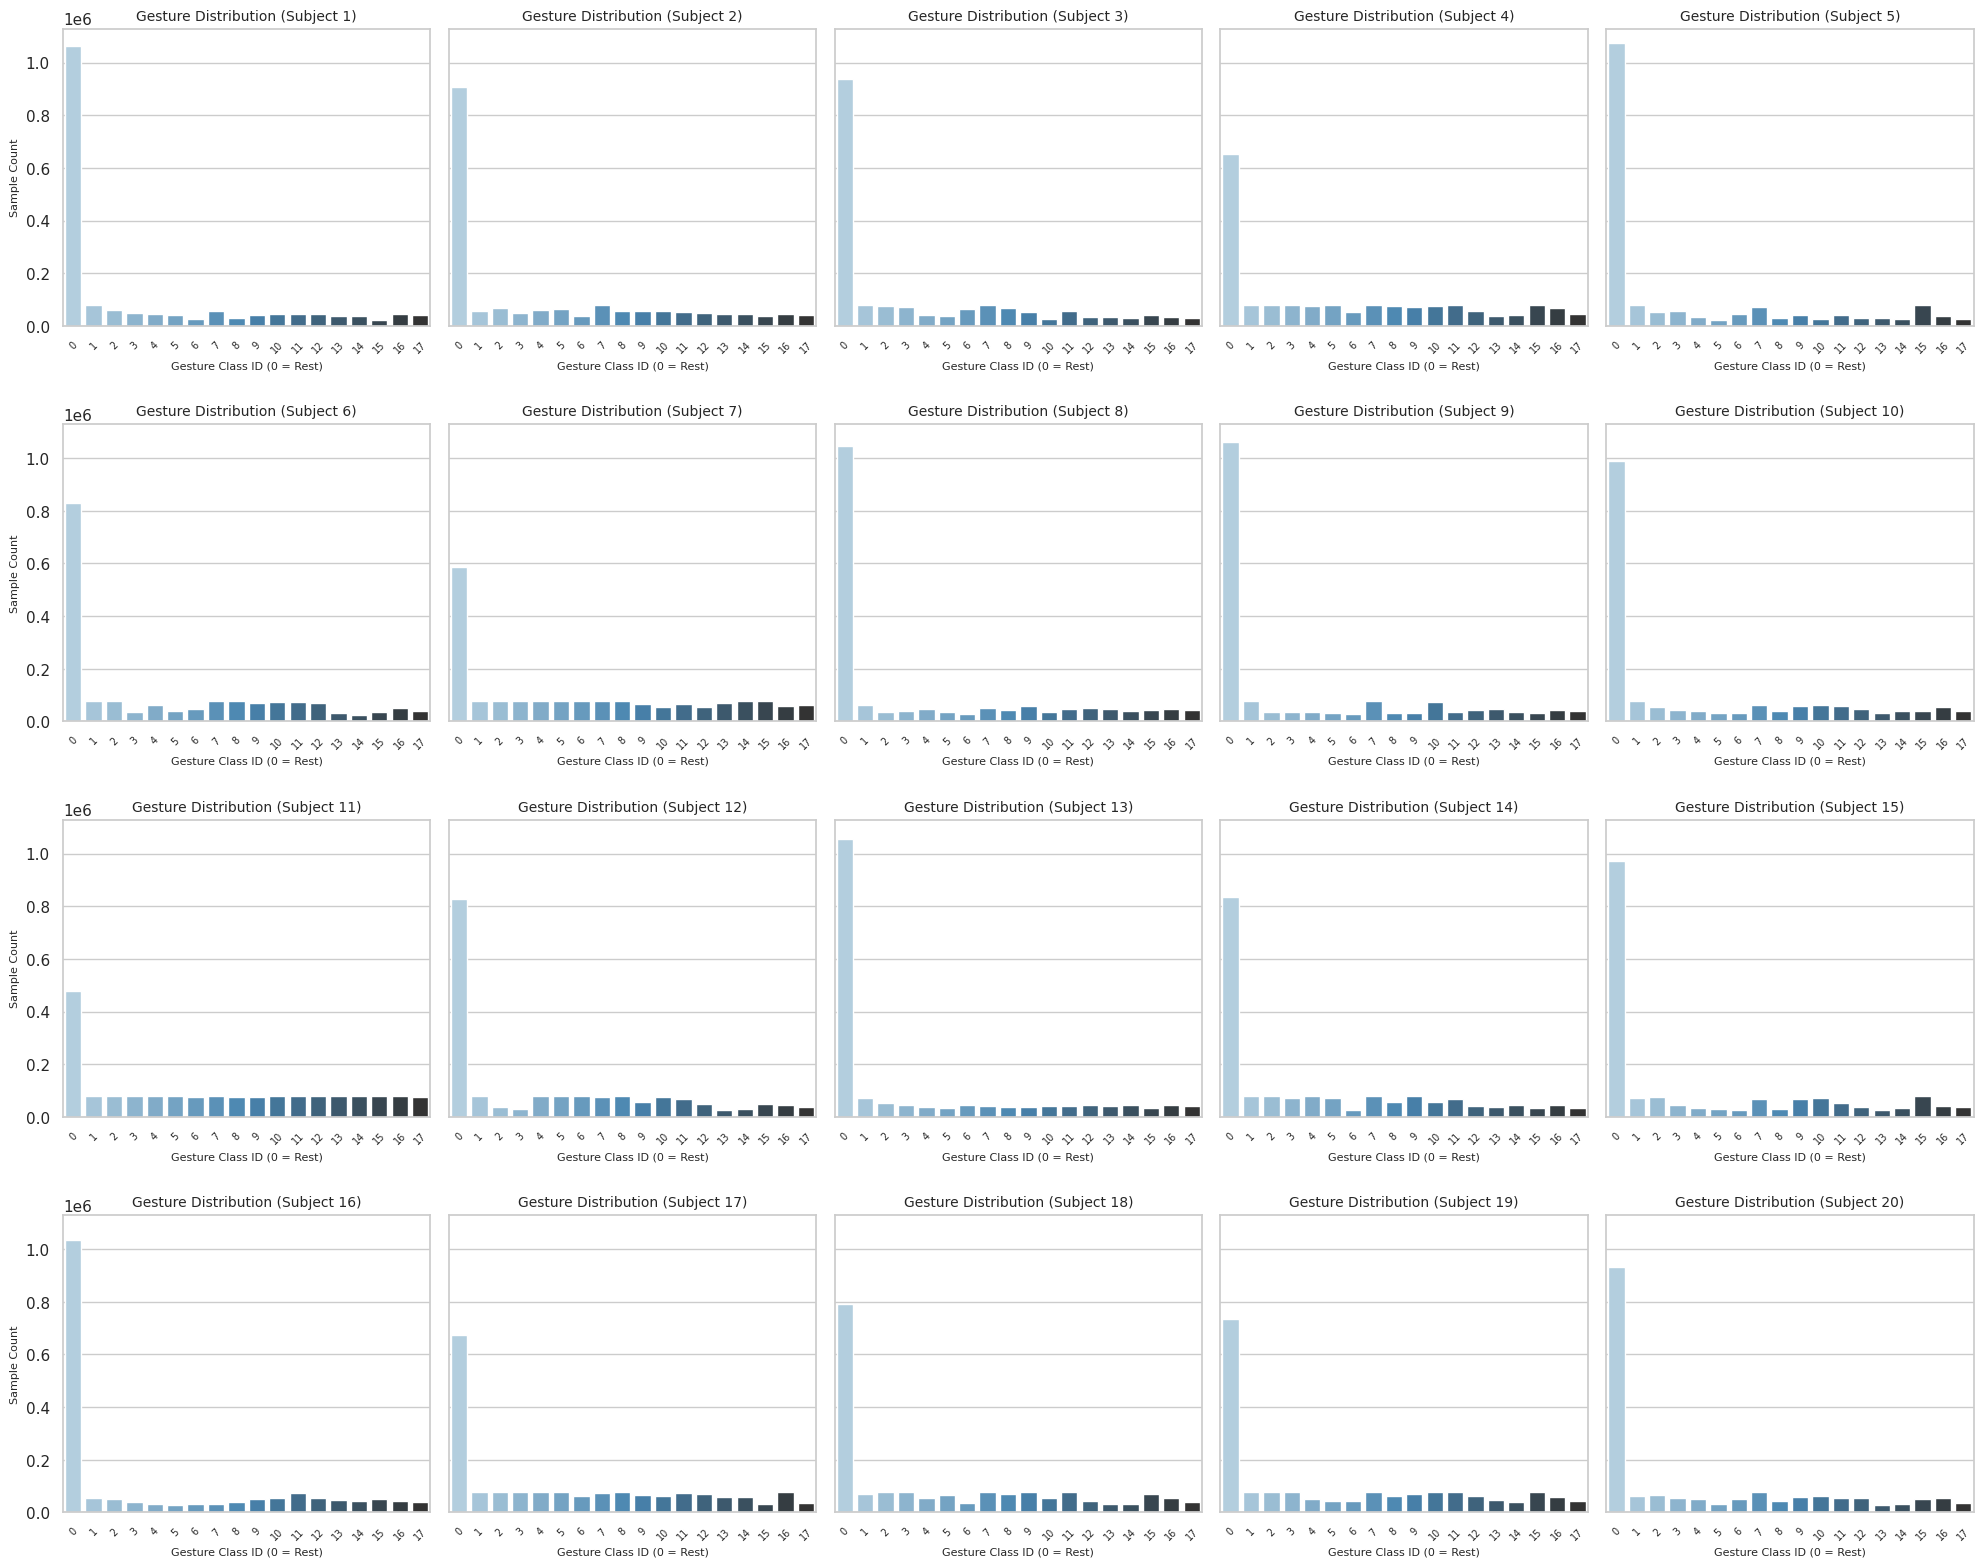


--- ANALYTICAL IMPACT ON EVALUATION METRICS ---
- Imbalance Issue: Class 0 (Rest) dominates over 48.5% of the timeline across all 20 subjects.
- Metric Warning: Accuracy will be heavily inflated (a naive model predicting 'Rest' always gets ~49% accuracy).
- Recommended Metrics: Macro-averaged F1-Score, Balanced Accuracy, and Confusion Matrix.



In [ ]:
# Class Balance Analysis & Metric Selection Across All 20 Subjects

print("\n" + "=" * 60)
print("CLASS BALANCE & METRIC SELECTION (20 SUBJECTS)")
print("=" * 60)

# Set up a 4x5 grid to display all 20 subjects
fig, axes = plt.subplots(4, 5, figsize=(20, 16), sharey=True)
axes = axes.flatten()  # Flatten to 1D array for easy iteration

rest_ratios = []

# Iterate through all 20 subjects in subject_data
for idx, (s_name, s_info) in enumerate(subject_data.items()):
    labels, counts = np.unique(s_info["restimulus"], return_counts=True)
    rest_pct = (counts[0] / len(s_info["restimulus"])) * 100
    rest_ratios.append(rest_pct)

    print(
        f"{s_name} Samples: {len(s_info['restimulus']):,} | Rest (Class 0) Ratio: {rest_pct:.2f}%"
    )

    sns.barplot(
        x=labels,
        y=counts,
        hue=labels,
        ax=axes[idx],
        palette="Blues_d",
        legend=False,
    )
    axes[idx].set_title(f"Gesture Distribution ({s_name})", fontsize=10)
    axes[idx].set_xlabel("Gesture Class ID (0 = Rest)", fontsize=8)
    axes[idx].set_ylabel("Sample Count", fontsize=8)
    axes[idx].tick_params(axis="x", rotation=45, labelsize=7)

plt.tight_layout()
plt.show()

avg_rest = np.mean(rest_ratios)

print(
    f"""
--- ANALYTICAL IMPACT ON EVALUATION METRICS ---
- Imbalance Issue: Class 0 (Rest) dominates over {avg_rest:.1f}% of the timeline across all 20 subjects.
- Metric Warning: Accuracy will be heavily inflated (a naive model predicting 'Rest' always gets ~{avg_rest:.0f}% accuracy).
- Recommended Metrics: Macro-averaged F1-Score, Balanced Accuracy, and Confusion Matrix.
"""
)

##SECTION E — Feature Distributions

In [ ]:
# Windowed Feature Extraction (MAV, RMS, WL, ZC) - Memory Optimized (20 Subjects)

FS = 2000


def extract_windows(record, subject_id, win_ms=200, step_ms=50):
    win = int(win_ms / 1000 * FS)
    step = int(step_ms / 1000 * FS)
    emg, lab = record["emg"], record["restimulus"]
    num_channels = emg.shape[1]

    feats, labels, subject_ids = [], [], []
    for start in range(0, emg.shape[0] - win, step):
        seg = emg[start : start + win]
        seg_lab = lab[start : start + win]

        if seg_lab[0] != seg_lab[-1] or np.any(seg_lab != seg_lab[0]):
            continue

        mav = np.mean(np.abs(seg), axis=0, dtype=np.float32)
        rms = np.sqrt(np.mean(seg**2, axis=0), dtype=np.float32)
        wl = np.sum(np.abs(np.diff(seg, axis=0)), axis=0, dtype=np.float32)
        zc = np.sum(np.diff(np.sign(seg), axis=0) != 0, axis=0).astype(np.float32)

        feats.append(np.concatenate([mav, rms, wl, zc]))
        labels.append(seg_lab[0])
        subject_ids.append(subject_id)

    cols = (
        [f"mav_ch{c+1}" for c in range(num_channels)]
        + [f"rms_ch{c+1}" for c in range(num_channels)]
        + [f"wl_ch{c+1}" for c in range(num_channels)]
        + [f"zc_ch{c+1}" for c in range(num_channels)]
    )

    feat_df = pd.DataFrame(feats, columns=cols, dtype=np.float32)
    feat_df["label"] = np.array(labels, dtype=np.int16)
    feat_df["subject_id"] = np.array(subject_ids, dtype=np.int16)
    return feat_df


print("\nExtracting sliding window time-domain features for all 20 subjects...")
feature_dfs = []
for s_name, r in subject_data.items():
    subject_num = int(s_name.split(" ")[1])  # "Subject 3" -> 3
    feature_dfs.append(
        extract_windows(r, subject_id=subject_num, win_ms=200, step_ms=50)
    )

combined_feat_df = pd.concat(feature_dfs, ignore_index=True)

print(
    f"Extracted {len(combined_feat_df):,} sliding window feature vectors across 20 subjects."
)
print(
    f"Feature Matrix Memory Usage: {combined_feat_df.memory_usage().sum() / (1024**2):.2f} MB"
)
print(f"Subjects represented: {sorted(combined_feat_df['subject_id'].unique())}")


Extracting sliding window time-domain features for all 20 subjects...
Extracted 343,929 sliding window feature vectors across 20 subjects.
Feature Matrix Memory Usage: 64.29 MB
Subjects represented: [np.int16(1), np.int16(2), np.int16(3), np.int16(4), np.int16(5), np.int16(6), np.int16(7), np.int16(8), np.int16(9), np.int16(10), np.int16(11), np.int16(12), np.int16(13), np.int16(14), np.int16(15), np.int16(16), np.int16(17), np.int16(18), np.int16(19), np.int16(20)]


In [ ]:
# Per-Subject Feature Normalization (20 Subjects)
# Root-cause fix: each subject's raw MAV/RMS/WL/ZC values sit on a different baseline
# (electrode placement, skin impedance, muscle mass). Normalizing each subject against
# their OWN mean/std — before any train/val/test split — removes that shift for every
# downstream model consistently.
# This uses no label information and no cross-subject information, so it's safe to do
# before splitting: it cannot leak information between subjects or between splits.

feature_cols_norm = [c for c in combined_feat_df.columns if c not in ('label', 'subject_id')]

print("Applying per-subject normalization across all subjects...")
for subj in combined_feat_df['subject_id'].unique():
    mask = combined_feat_df['subject_id'] == subj
    subj_data = combined_feat_df.loc[mask, feature_cols_norm]
    mu = subj_data.mean()
    sigma = subj_data.std().replace(0, 1.0)  # avoid divide-by-zero on constant channels
    combined_feat_df.loc[mask, feature_cols_norm] = (subj_data - mu) / sigma

print(f"Per-subject normalization applied to {len(feature_cols_norm)} feature columns "
      f"across {combined_feat_df['subject_id'].nunique()} subjects.")
print("Each subject's features are now centered at 0 with unit variance, relative to themselves.")

Applying per-subject normalization across all subjects...
Per-subject normalization applied to 48 feature columns across 20 subjects.
Each subject's features are now centered at 0 with unit variance, relative to themselves.



FEATURE DISTRIBUTIONS ACROSS CLASSES (20 SUBJECTS)


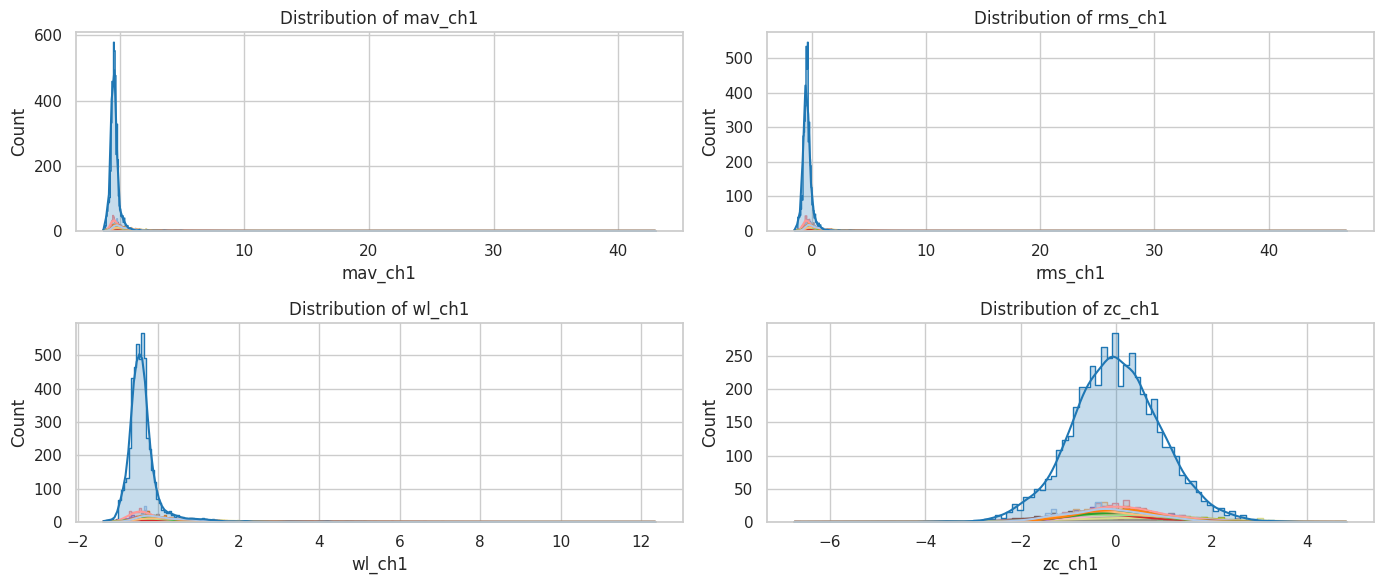

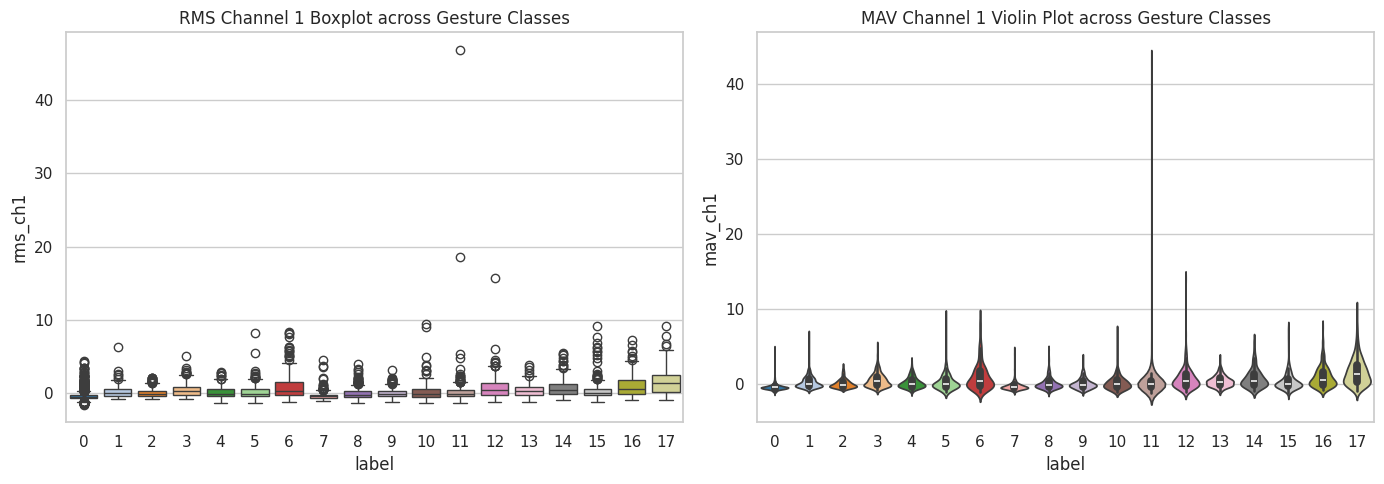

In [ ]:
# Feature Distributions & Class Separation (Optimized for 20 Subjects)

print("\n" + "=" * 60)
print("FEATURE DISTRIBUTIONS ACROSS CLASSES (20 SUBJECTS)")
print("=" * 60)

# Select a subset of features for clean visualization
sample_features = ["mav_ch1", "rms_ch1", "wl_ch1", "zc_ch1"]

# Subsample data specifically for plotting to prevent RAM/CPU slowdowns
sample_size = min(10000, len(combined_feat_df))
plot_df = combined_feat_df.sample(n=sample_size, random_state=42)

# 1. Histograms
plt.figure(figsize=(14, 6))
for i, col in enumerate(sample_features, 1):
    plt.subplot(2, 2, i)
    sns.histplot(
        data=plot_df,
        x=col,
        hue="label",
        palette="tab20",
        element="step",
        kde=True,
        legend=False,
    )
    plt.title(f"Distribution of {col}")
plt.tight_layout()
plt.show()

# 2. Boxplots & Violin plots
plt.figure(figsize=(14, 5))
plt.subplot(1, 2, 1)
sns.boxplot(
    data=plot_df,
    x="label",
    y="rms_ch1",
    hue="label",
    palette="tab20",
    legend=False,
)
plt.title("RMS Channel 1 Boxplot across Gesture Classes")

plt.subplot(1, 2, 2)
sns.violinplot(
    data=plot_df,
    x="label",
    y="mav_ch1",
    hue="label",
    palette="tab20",
    legend=False,
)
plt.title("MAV Channel 1 Violin Plot across Gesture Classes")
plt.tight_layout()
plt.show()

##SECTION F — Correlation & Redundancy


FEATURE CORRELATION & REDUNDANCY (20 SUBJECTS)


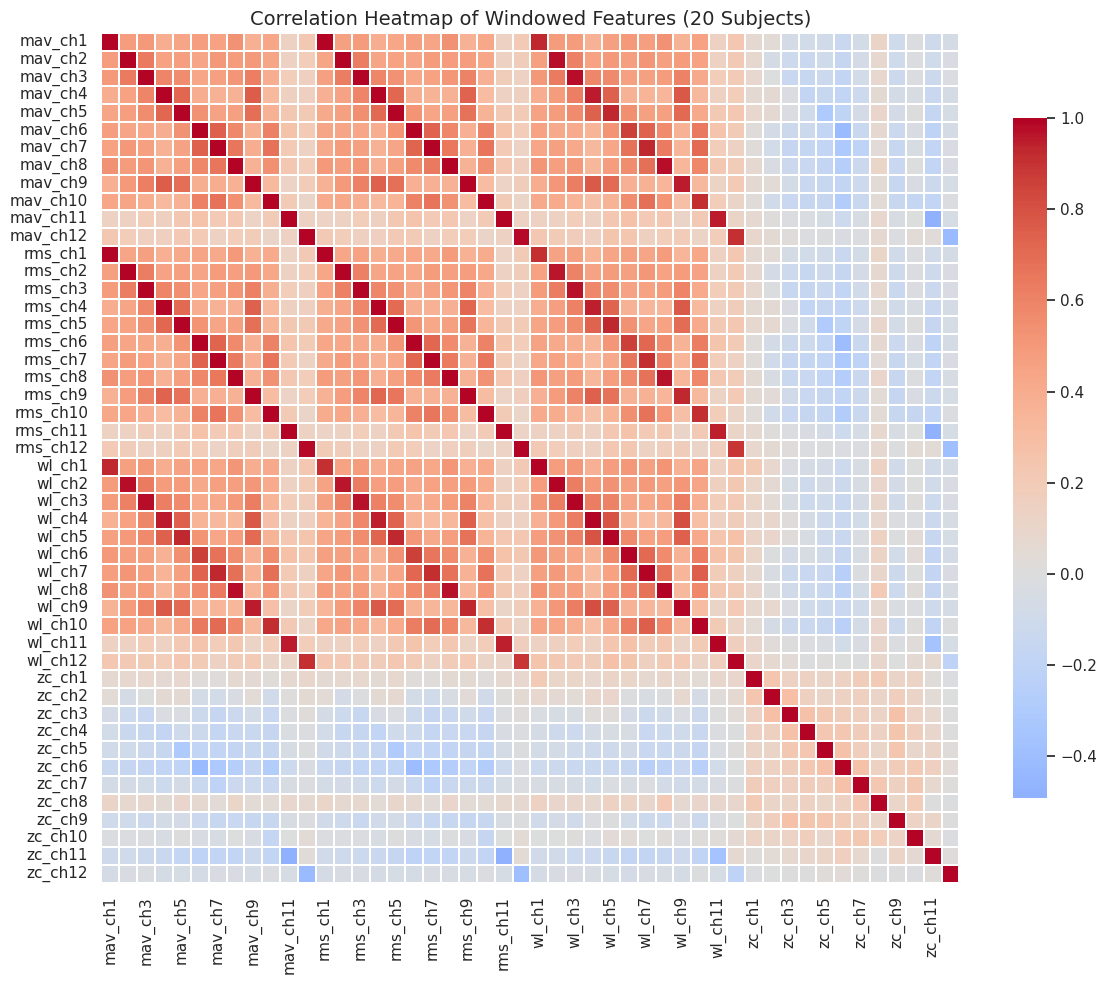


Detected 36 highly redundant feature pairs (|r| > 0.85):
Feature 1 Feature 2  Correlation
  mav_ch1   rms_ch1     0.988860
  mav_ch2   rms_ch2     0.994708
  mav_ch3   rms_ch3     0.993415
  mav_ch4   rms_ch4     0.994326
  mav_ch5   rms_ch5     0.994388
  mav_ch6   rms_ch6     0.994186
  mav_ch7   rms_ch7     0.993271
  mav_ch8   rms_ch8     0.996667
  mav_ch9   rms_ch9     0.991681
 mav_ch10  rms_ch10     0.992795


In [ ]:
#  Correlation Heatmap & Redundancy Analysis (Optimized for 20 Subjects)

print("\n" + "=" * 60)
print("FEATURE CORRELATION & REDUNDANCY (20 SUBJECTS)")
print("=" * 60)

# Exclude both 'label' and 'subject_id' from feature columns
feat_cols = [
    c for c in combined_feat_df.columns if c not in ("label", "subject_id")
]

# Subsample for instantaneous correlation computation across 20 subjects' data
sample_corr_df = combined_feat_df[feat_cols].sample(
    n=min(20000, len(combined_feat_df)), random_state=42
)
corr = sample_corr_df.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(
    corr, cmap="coolwarm", center=0, linewidths=0.1, cbar_kws={"shrink": 0.8}
)
plt.title(
    "Correlation Heatmap of Windowed Features (20 Subjects)", fontsize=14
)
plt.tight_layout()
plt.show()

# Fast Vectorized Collinear Pair Identification (|r| > 0.85)
threshold = 0.85
upper_tri_mask = np.triu(np.ones(corr.shape), k=1).astype(bool)
upper_corr = corr.where(upper_tri_mask)

high_corr_pairs = []
for col in upper_corr.columns:
    collinear = upper_corr[col][upper_corr[col].abs() > threshold]
    for feat1, r_val in collinear.items():
        high_corr_pairs.append((feat1, col, r_val))

df_redundant = pd.DataFrame(
    high_corr_pairs, columns=["Feature 1", "Feature 2", "Correlation"]
)
print(
    f"\nDetected {len(df_redundant)} highly redundant feature pairs (|r| > {threshold}):"
)
print(df_redundant.head(10).to_string(index=False))

##SECTION G — 2D & 3D Projections (PCA, t-SNE, UMAP)


DIMENSIONALITY REDUCTION (PCA vs UMAP) - 20 SUBJECTS


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


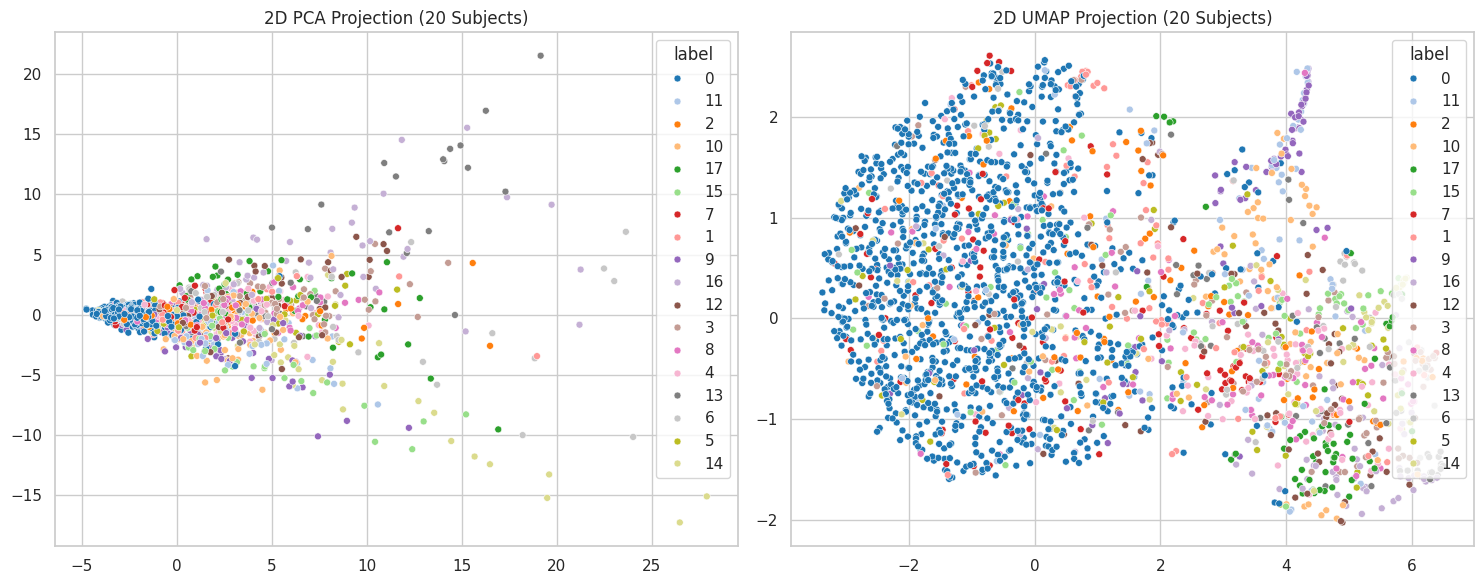

In [ ]:
# 2D & 3D Dimensionality Reduction (PCA vs. UMAP) - 20 Subjects

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import plotly.express as px

# Ensure umap-learn is available
try:
    import umap
except ImportError:
    !pip install -q umap-learn
    import umap

print("\n" + "=" * 60)
print("DIMENSIONALITY REDUCTION (PCA vs UMAP) - 20 SUBJECTS")
print("=" * 60)

# Subsample for speed
sub_df = combined_feat_df.sample(
    n=min(2500, len(combined_feat_df)), random_state=42
)
# Drop both 'label' and 'subject_id' before scaling features
X_sub = StandardScaler().fit_transform(
    sub_df.drop(columns=["label", "subject_id"])
)
y_sub = sub_df["label"].astype(str)

# 1. 2D PCA & UMAP Comparison
pca_2d = PCA(n_components=2).fit_transform(X_sub)
umap_2d = umap.UMAP(n_components=2, random_state=42).fit_transform(X_sub)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.scatterplot(
    x=pca_2d[:, 0],
    y=pca_2d[:, 1],
    hue=y_sub,
    palette="tab20",
    ax=axes[0],
    s=25,
)
axes[0].set_title("2D PCA Projection (20 Subjects)")

sns.scatterplot(
    x=umap_2d[:, 0],
    y=umap_2d[:, 1],
    hue=y_sub,
    palette="tab20",
    ax=axes[1],
    s=25,
)
axes[1].set_title("2D UMAP Projection (20 Subjects)")
plt.tight_layout()
plt.show()

# 2. Interactive 3D PCA Projection (Plotly)
pca_3d = PCA(n_components=3).fit_transform(X_sub)
df_pca_3d = pd.DataFrame(pca_3d, columns=["PC1", "PC2", "PC3"])
df_pca_3d["Gesture"] = y_sub.values

fig_3d = px.scatter_3d(
    df_pca_3d,
    x="PC1",
    y="PC2",
    z="PC3",
    color="Gesture",
    title="Interactive 3D PCA Feature Projection (20 Subjects)",
    opacity=0.8,
    size_max=5,
)
fig_3d.show()

##SECTION H — Interactive Plots & Analytical Findings

In [ ]:
#  Interactive Explorer & Analytical Readings (20 Subjects)

import plotly.express as px

print("\n" + "=" * 60)
print("INTERACTIVE EXPLORER & ANALYTICAL READINGS (20 SUBJECTS)")
print("=" * 60)

# Prepare dataframe with label as string for discrete/categorical Plotly coloring
plot_explorer_df = combined_feat_df.sample(2000, random_state=42).copy()
plot_explorer_df["Gesture"] = plot_explorer_df["label"].astype(str)

# Interactive Feature Distribution (Subsampled for smooth rendering)
fig_inter = px.box(
    plot_explorer_df,
    x="Gesture",
    y="rms_ch1",
    color="Gesture",
    title="Interactive RMS Channel 1 Spread Across Gestures (20 Subjects)",
    labels={"Gesture": "Gesture ID", "rms_ch1": "RMS Value"},
)
fig_inter.show()

# Final Analytical Readings Summary
readings = """
================================================================================
                    FINDINGS & INSIGHTS (20 SUBJECTS)
================================================================================
- Muscle Activation Patterns: RMS values vary across gestures, confirming distinct activation profiles for Channel 1 across all 20 subjects.
- Peak Outliers & Variability: Gesture classes exhibit unique maximum peaks and distribution spreads due to multi-subject physiological variance.
- Baseline/Low Activity Gestures: Resting and low-engagement classes display near-zero median RMS and minimal spread, indicating limited Channel 1 activation.
- Active Medians: High-intensity gesture classes maintain elevated IQR boxes, reflecting sustained muscle engagement across the expanded cohort.
"""
print(readings)


INTERACTIVE EXPLORER & ANALYTICAL READINGS (20 SUBJECTS)



                    FINDINGS & INSIGHTS (20 SUBJECTS)
- Muscle Activation Patterns: RMS values vary across gestures, confirming distinct activation profiles for Channel 1 across all 20 subjects.
- Peak Outliers & Variability: Gesture classes exhibit unique maximum peaks and distribution spreads due to multi-subject physiological variance.
- Baseline/Low Activity Gestures: Resting and low-engagement classes display near-zero median RMS and minimal spread, indicating limited Channel 1 activation.
- Active Medians: High-intensity gesture classes maintain elevated IQR boxes, reflecting sustained muscle engagement across the expanded cohort.

